# EDA (Explotary Data Analysis Process)

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('..\Data\Dopamine_D2_receptor_03_bioactivity_data_raw.csv')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HP\AppData\Local\Temp\ipykernel_12584\1651180115.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('..\Data\Dopamine_D2_receptor_03_bioactivity_data_raw.csv')


In [6]:
df.head()

,Unnamed: 0,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,0,CHEMBL303519,c1cnc(N2CCN(Cc3cccc4c3Cc3ccccc3-4)CC2)nc1,342.446,3.3700,0.0,4.0,5.008774
1,1,CHEMBL292943,COc1ccc(-c2cccc(CN3CCN(c4ncccn4)CC3)c2)cc1,360.461,3.4744,0.0,5.0,7.301030
2,2,CHEMBL61682,Fc1ccc(-c2cncc(CN3CCN(c4ccccc4F)CC3)c2)cc1,365.427,4.3490,0.0,3.0,7.602060
3,3,CHEMBL64487,COc1ccccc1-c1cccc(CN2CCN(c3ncccn3)CC2)c1,360.461,3.4744,0.0,5.0,6.443697
4,4,CHEMBL64597,c1cnc(N2CCN(Cc3cccc(-c4ccsc4)c3)CC2)nc1,336.464,3.5273,0.0,5.0,6.522879


### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

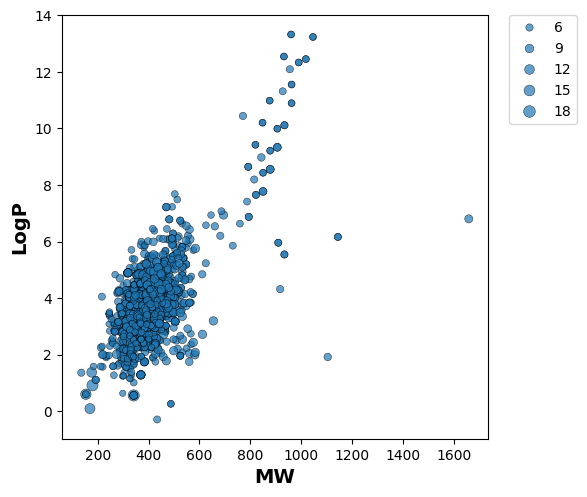

In [7]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df, size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### check the data is concistant or not

#### **pIC50 value**

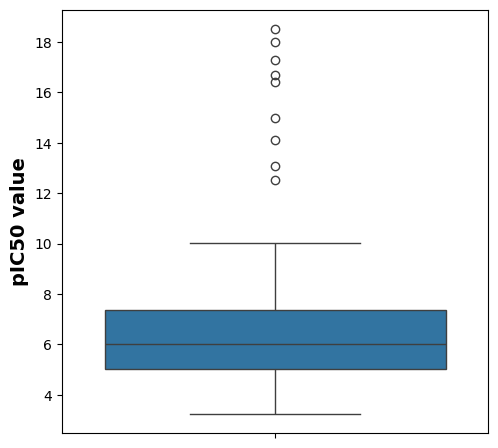

In [12]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(y = 'pIC50', data = df)

plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50_box.pdf')

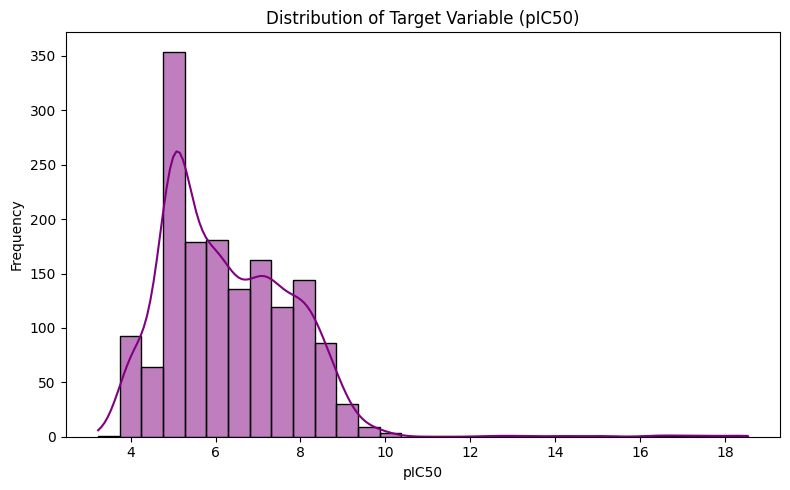

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['pIC50'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of Target Variable (pIC50)')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.savefig('pIC50_distribution.png')


In [15]:
Q1 = df['pIC50'].quantile(0.25)
Q3 = df['pIC50'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the data for values outside the bounds
outliers_iqr = df[(df['pIC50'] < lower_bound) | (df['pIC50'] > upper_bound)]

print("IQR Outliers:")
print(outliers_iqr)

IQR Outliers:
     Unnamed: 0 molecule_chembl_id  \
92           92       CHEMBL225230   
94           94       CHEMBL267044   
96           96        CHEMBL26736   
97           97       CHEMBL225230   
98           98       CHEMBL267930   
99           99      CHEMBL1255588   
100         100           CHEMBL39   
101         101           CHEMBL59   
102         102         CHEMBL1437   

                                      canonical_smiles       MW    LogP  \
92             CCCN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3  295.382  3.6301   
94          CCN1CCC[C@H]1CNC(=O)c1cc(S(N)(=O)=O)ccc1OC  341.433  0.5567   
96                               NC1CCc2cc(O)c(O)cc2C1  179.219  0.9138   
97             CCCN1CCc2cccc3c2[C@H]1Cc1ccc(O)c(O)c1-3  295.382  3.6301   
98     O=C(CCCN1CCC2(CC1)C(=O)NCN2c1ccccc1)c1ccc(F)cc1  395.478  3.2171   
99   CC(C)(C)[C@@]1(O)CCN2C[C@@H]3c4ccccc4CCc4cccc(...  361.529  4.8448   
100                             NCCc1c[nH]c2ccc(O)cc12  176.219  1.3747   
101  

### the data have only 9 outliers of 1537 value and they not extreme values so we will not drop them and the distribution is almost perfect normally distributed so it will be helpful when use as y column

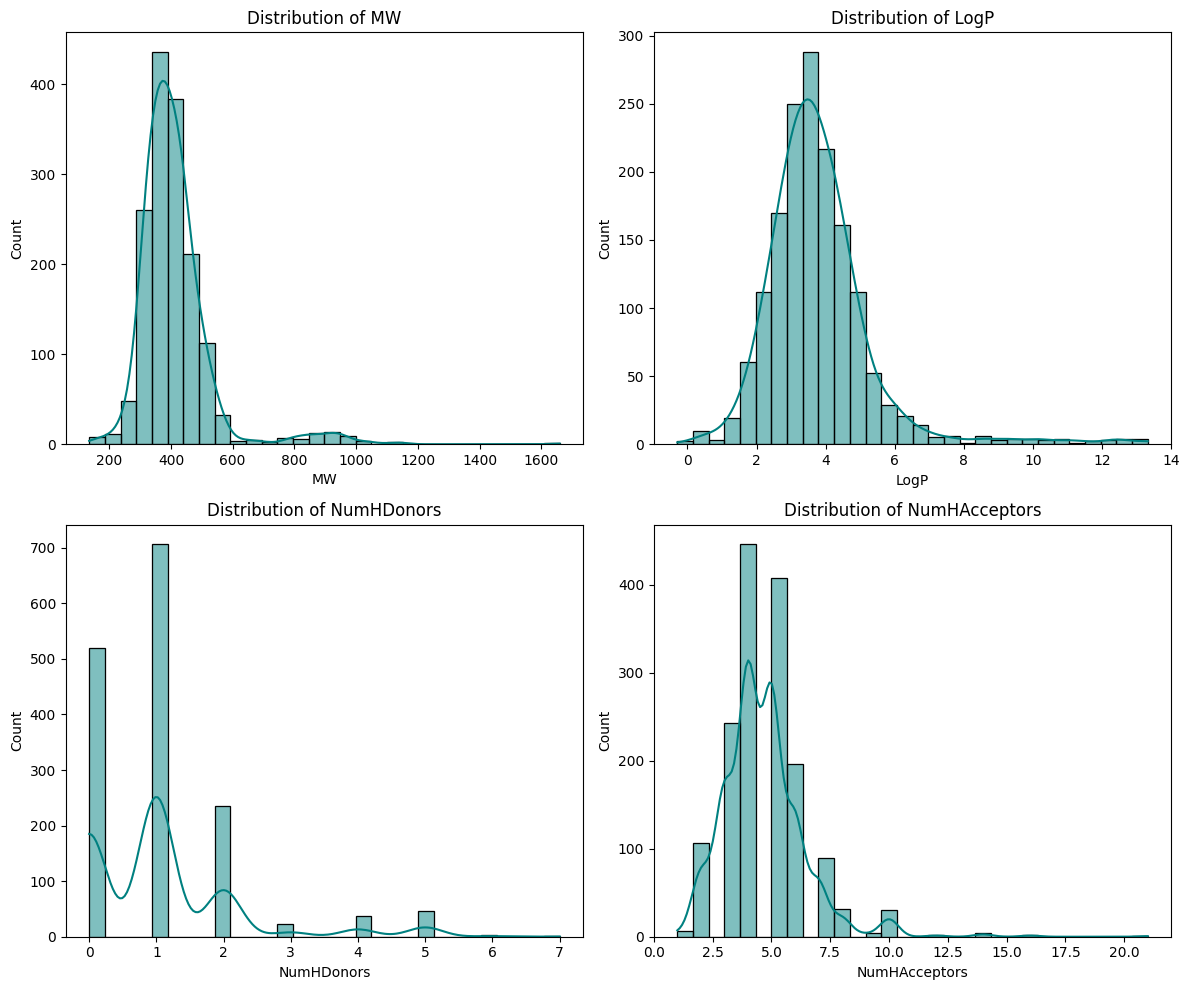

<Figure size 640x480 with 0 Axes>

In [18]:
features = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(features):
    row, col = divmod(i, 2)
    sns.histplot(df[feature].dropna(), bins=30, kde=True, ax=axes[row, col], color='teal')
    axes[row, col].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show() 
plt.savefig('lipinski_distributions.png')

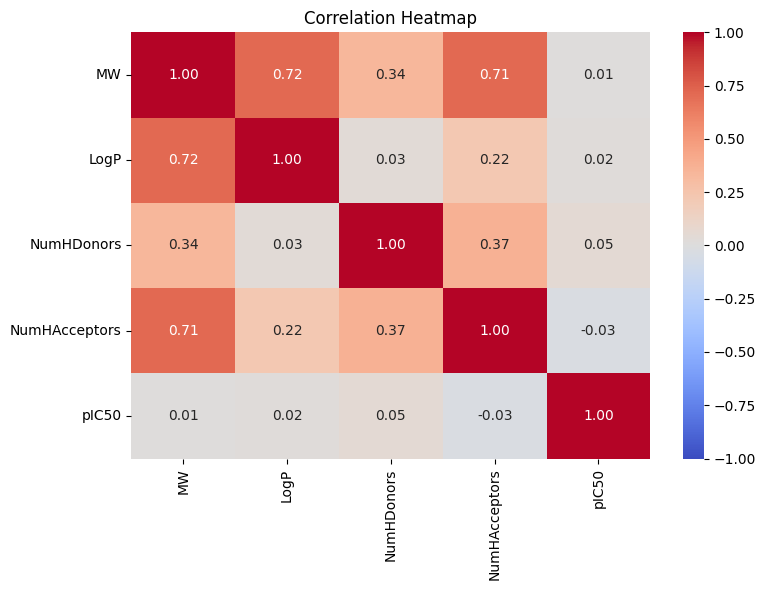

<Figure size 640x480 with 0 Axes>

In [19]:
plt.figure(figsize=(8, 6))
# Select only the numerical columns we want to correlate
cols_to_correlate = ['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
correlation_matrix = df[cols_to_correlate].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show() 
plt.savefig('correlation_heatmap.png')

### the relation exict only for MW with numHAcceptors and LogP either there is no multicolinearty

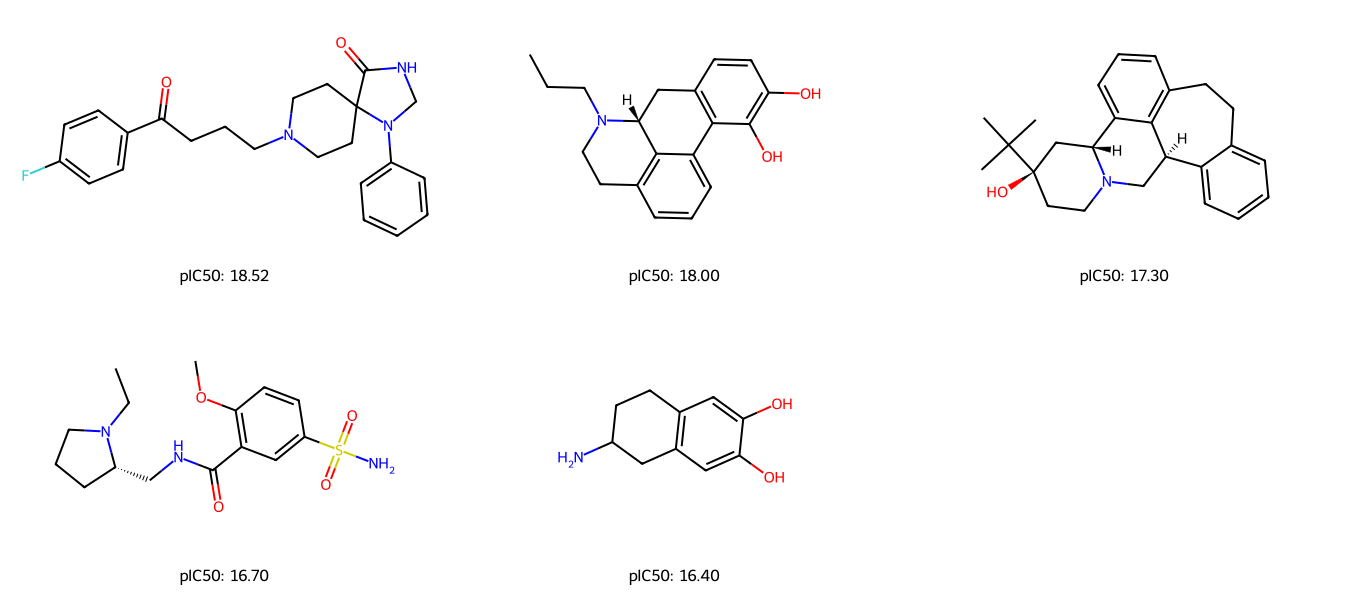

In [25]:
from rdkit.Chem import Draw
top_active = df.sort_values(by='pIC50', ascending=False).head(5)

# Draw the top 5 active molecules
mols = [Chem.MolFromSmiles(smiles) for smiles in top_active['canonical_smiles']]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(450, 300), legends=[f"pIC50: {val:.2f}" for val in top_active['pIC50']])



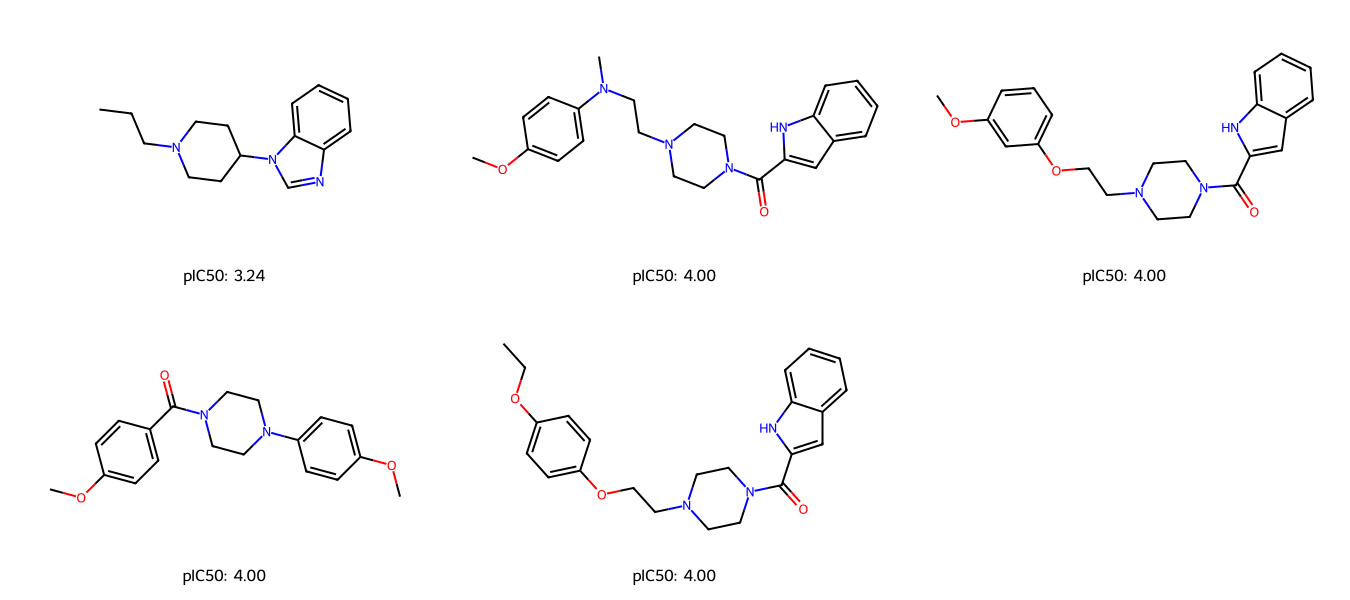

In [26]:
# Draw the least 5 active molecules
least_active = df.sort_values(by='pIC50', ascending=True).head(5)
mols = [Chem.MolFromSmiles(smiles) for smiles in least_active['canonical_smiles']]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(450, 300), legends=[f"pIC50: {val:.2f}" for val in least_active['pIC50']])


### Scaffold Analysis (Murcko Scaffolds)
If 80% of dataset shares the same core, the machine learning model will be biased

In [27]:
from rdkit.Chem.Scaffolds import MurckoScaffold

# Extract the core scaffold for each molecule
df['scaffold_smiles'] = df['canonical_smiles'].apply(lambda x: MurckoScaffold.MurckoScaffoldSmiles(mol=Chem.MolFromSmiles(x)) if Chem.MolFromSmiles(x) else None)

# Count how many unique scaffolds exist and find the most common ones
scaffold_counts = df['scaffold_smiles'].value_counts()
print(f"Total unique molecules: {len(df)}")
print(f"Total unique scaffolds: {len(scaffold_counts)}")
print("\nTop 5 most common scaffolds:")
print(scaffold_counts.head())

Total unique molecules: 1570
Total unique scaffolds: 601

Top 5 most common scaffolds:
scaffold_smiles
O=C(NCC1CCCN1)c1ccccc1                        81
N=C(CCN1CCN(c2ccccn2)CC1)c1ccccc1             75
O=C(c1cc2ccccc2[nH]1)N1CCN(CCOc2ccccc2)CC1    54
c1ccc2c(c1)CC1NCCc3cccc-2c31                  39
c1ccc(C2CC2CN2CCN(c3ccccc3)CC2)cc1            27
Name: count, dtype: int64


In [28]:
Scaffold_percent =( len(scaffold_counts) / len(df) ) * 100
Scaffold_percent

38.28025477707007

### Scaffold Analysis (Murcko Scaffolds) Result
The percentage is 38.2% which make the data relaible for make the ML model

## Check for how many Oral Drug likely molecules in the data

In [29]:
def calculate_ro5_violations(row):
    violations = 0
    if row['MW'] > 500: violations += 1
    if row['LogP'] > 5: violations += 1
    if row['NumHDonors'] > 5: violations += 1
    if row['NumHAcceptors'] > 10: violations += 1
    return violations

# Apply the function to create a new column
df['Ro5_Violations'] = df.apply(calculate_ro5_violations, axis=1)

# Print out the counts to see how many molecules break the rules
print("Lipinski Rule of 5 Violations Count:")
print(df['Ro5_Violations'].value_counts().sort_index())



Lipinski Rule of 5 Violations Count:
Ro5_Violations
0    1311
1     155
2      97
3       6
4       1
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_12584\2732206482.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ro5_Violations', y='pIC50', data=df, palette='Set2')


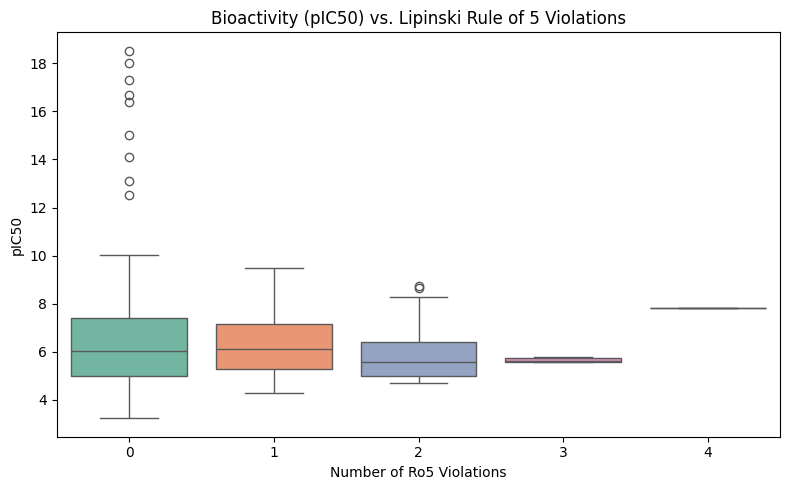

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Ro5_Violations', y='pIC50', data=df, palette='Set2')

# Add labels and title
plt.title('Bioactivity (pIC50) vs. Lipinski Rule of 5 Violations')
plt.xlabel('Number of Ro5 Violations')
plt.ylabel('pIC50')

# Show the plot
plt.tight_layout()
plt.show()

### Most of the componds can be used as oral active compunds as 1311 of 1537 is oral active which make those cpds helpful for drug design process